# Currency Crisis Prediction – Modelling Pipeline

Early warning system for currency crises across **22 emerging markets (1974–2026)**.

| | |
|---|---|
| **Holdout country** | Philippines — never seen during training or threshold tuning |
| **Target** | `crisis_in_6m`  (1 = any crisis event within the next 6 months) |
| **Features** | 37 total: 15 base macroeconomic + 7 month-over-month differences + 15 lag features |

### Pipeline Overview
1. **Exploratory Data Analysis** — class balance, crisis timeline, feature distributions, Philippines time series
2. **Baseline: Logistic Regression** — trained on SMOTE-balanced data, CV-averaged decision threshold
3. **Random Forest** — 5-fold expanding-window time-series cross-validation, SHAP interpretability
4. **Model Comparison** — ROC / PR curves, threshold sensitivity, probability calibration

In [1]:
%matplotlib inline
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score, f1_score,
)
from sklearn.calibration import CalibrationDisplay
import shap

warnings.filterwarnings("ignore")

# Resolve the directory where this notebook lives
try:
    SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    SCRIPT_DIR = os.getcwd()   # Jupyter: working directory = notebook directory

PLOT_DIR = os.path.join(SCRIPT_DIR, "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

TARGET           = "crisis_in_6m"
BACKTEST_COUNTRY = "Philippines"

print(f"Working directory : {SCRIPT_DIR}")
print(f"Plots will be saved to : {PLOT_DIR}")

C:\Users\chaij\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Working directory : C:\Users\chaij\OneDrive\Documents\Data Science Group Coursework\data-science-2026-data-collection-main\data-science-2026-data-collection-main\data-science-2026-data-collection\preprocess
Plots will be saved to : C:\Users\chaij\OneDrive\Documents\Data Science Group Coursework\data-science-2026-data-collection-main\data-science-2026-data-collection-main\data-science-2026-data-collection\preprocess\plots


In [2]:
# ── Base features (15) ────────────────────────────────────────────────────────
# interest_differential and trade_to_reserves are excluded due to high
# collinearity with real_interest_rate and capital_flow_pct respectively
FEATURES_BASE = [
    "real_interest_rate",
    "fx_depreciation_mom",
    "reserves_change_mom",     "reserves_change_yoy",
    "reserve_adequacy_months", "m2_reserves_ratio",
    "inflation_accel_3m",      "Inflation_YoY_%",
    "capital_flow_pct",        "export_growth_yoy",
    "m2_growth_yoy",           "credit_boom_yoy",
    "reer_misalignment",       "std_vulnerability",
    "reserves_to_std_proxy",
]

# ── Month-over-month differences (7) ──────────────────────────────────────────
# Capture rate-of-change for the most structurally important indicators
FEATURES_DIFF = [
    "reserve_adequacy_months_diff", "m2_reserves_ratio_diff",
    "Inflation_YoY_%_diff",         "m2_growth_yoy_diff",
    "reer_misalignment_diff",       "std_vulnerability_diff",
    "reserves_to_std_proxy_diff",
]

# ── Lag features (5 indicators x 3 lags = 15) ─────────────────────────────────
# 1-, 3-, and 6-month lags capture momentum and delayed crisis signals
FEATURES_LAG = [
    "reserves_change_mom_lag1", "reserves_change_mom_lag3", "reserves_change_mom_lag6",
    "Inflation_YoY_%_lag1",     "Inflation_YoY_%_lag3",     "Inflation_YoY_%_lag6",
    "fx_depreciation_mom_lag1", "fx_depreciation_mom_lag3", "fx_depreciation_mom_lag6",
    "reer_misalignment_lag1",   "reer_misalignment_lag3",   "reer_misalignment_lag6",
    "capital_flow_pct_lag1",    "capital_flow_pct_lag3",    "capital_flow_pct_lag6",
]

# emp_index is excluded: it is a linear combination of fx_depreciation_mom,
# reserves_change_mom, and real_interest_rate — three features already in the set.
# Including it would artificially dominate feature importance rankings.
FEATURES_EXT = FEATURES_BASE + FEATURES_DIFF + FEATURES_LAG  # 37 total

# Human-readable labels for plots
FEATURE_LABELS = {
    "real_interest_rate":           "Real Interest Rate",
    "fx_depreciation_mom":          "FX Depreciation (MoM %)",
    "reserves_change_mom":          "Reserve Change (MoM %)",
    "reserves_change_yoy":          "Reserve Change (YoY %)",
    "reserve_adequacy_months":      "Reserve Adequacy (Months)",
    "m2_reserves_ratio":            "M2 / Reserves Ratio",
    "inflation_accel_3m":           "Inflation Accel (3M)",
    "Inflation_YoY_%":              "Inflation (YoY %)",
    "capital_flow_pct":             "Capital Flow (% Reserves)",
    "export_growth_yoy":            "Export Growth (YoY %)",
    "m2_growth_yoy":                "M2 Growth (YoY %)",
    "credit_boom_yoy":              "Credit Boom (YoY %)",
    "reer_misalignment":            "REER Misalignment",
    "std_vulnerability":            "Short-Term Debt Vulnerability",
    "reserves_to_std_proxy":        "Reserves-to-STD Proxy",
    "reserve_adequacy_months_diff": "Reserve Adequacy Delta",
    "m2_reserves_ratio_diff":       "M2/Reserves Delta",
    "Inflation_YoY_%_diff":         "Inflation Delta (1M)",
    "m2_growth_yoy_diff":           "M2 Growth Delta",
    "reer_misalignment_diff":       "REER Misalign Delta",
    "std_vulnerability_diff":       "STD Vulnerability Delta",
    "reserves_to_std_proxy_diff":   "Reserves/STD Proxy Delta",
    "reserves_change_mom_lag1":     "Reserve Chg Lag-1",
    "reserves_change_mom_lag3":     "Reserve Chg Lag-3",
    "reserves_change_mom_lag6":     "Reserve Chg Lag-6",
    "Inflation_YoY_%_lag1":         "Inflation Lag-1",
    "Inflation_YoY_%_lag3":         "Inflation Lag-3",
    "Inflation_YoY_%_lag6":         "Inflation Lag-6",
    "fx_depreciation_mom_lag1":     "FX Depr Lag-1",
    "fx_depreciation_mom_lag3":     "FX Depr Lag-3",
    "fx_depreciation_mom_lag6":     "FX Depr Lag-6",
    "reer_misalignment_lag1":       "REER Lag-1",
    "reer_misalignment_lag3":       "REER Lag-3",
    "reer_misalignment_lag6":       "REER Lag-6",
    "capital_flow_pct_lag1":        "Capital Flow Lag-1",
    "capital_flow_pct_lag3":        "Capital Flow Lag-3",
    "capital_flow_pct_lag6":        "Capital Flow Lag-6",
}

COLOR_NO_CRISIS = "#2196F3"
COLOR_CRISIS    = "#F44336"
COLOR_LR        = "#1565C0"
COLOR_RF        = "#2E7D32"

print(f"Feature set: {len(FEATURES_EXT)} total "
      f"({len(FEATURES_BASE)} base + {len(FEATURES_DIFF)} diff + {len(FEATURES_LAG)} lag)")

Feature set: 37 total (15 base + 7 diff + 15 lag)


In [3]:
def best_threshold(y_true, y_proba):
    """Return the decision threshold that maximises F1 for the crisis (positive) class."""
    precs, recs, thrs = precision_recall_curve(y_true, y_proba)
    f1s = np.where((precs + recs) == 0, 0, 2 * precs * recs / (precs + recs))
    return float(thrs[np.argmax(f1s[:-1])])


def prior_correct(proba, real_rate, train_rate=0.5):
    """Re-calibrate SMOTE probabilities to the real base rate via log-odds shift.

    A model trained on SMOTE-balanced data (50 % crisis) outputs probabilities
    centred at 0.5. The real crisis rate is ~14 %, so a Bayesian log-odds
    correction shifts the outputs before thresholding.
    """
    eps = 1e-9
    log_odds   = np.log(proba / (1 - proba + eps) + eps)
    adjustment = (np.log(real_rate  / (1 - real_rate))
                - np.log(train_rate / (1 - train_rate)))
    return 1.0 / (1.0 + np.exp(-(log_odds + adjustment)))


def save(fig, name):
    """Save the figure to the plots directory and display it inline."""
    fig.savefig(os.path.join(PLOT_DIR, name), dpi=150, bbox_inches="tight")
    plt.show()

In [4]:
# Load all data files from the preprocess/ directory
raw     = pd.read_csv(os.path.join(SCRIPT_DIR, "features_raw.csv"),
                      parse_dates=["Date"])        # raw panel — all countries
rob     = pd.read_csv(os.path.join(SCRIPT_DIR, "features_robust.csv"),
                      parse_dates=["Date"])        # RobustScaler-normalised (used by LR)
smote   = pd.read_csv(os.path.join(SCRIPT_DIR, "train_smote.csv"))
                                                   # SMOTE-balanced training set (used by LR)
cv_plan = pd.read_csv(os.path.join(SCRIPT_DIR, "cv_fold_plan.csv"),
                      parse_dates=["train_start","train_end","test_start","test_end"])
                                                   # 5-fold expanding-window schedule

# Drop rows without a label, sort by time, ensure integer target
for df in [raw, rob]:
    df.dropna(subset=[TARGET], inplace=True)
    df.sort_values(["Date", "Country"], inplace=True)
    df.reset_index(drop=True, inplace=True)
    df[TARGET] = df[TARGET].astype(int)

smote[TARGET] = smote[TARGET].astype(int)

# Fill feature NaNs with 0 (missing = no change for rate/ratio features)
raw_f = raw.fillna(0).copy()
rob_f = rob.fillna(0).copy()

print(f"features_raw    : {raw.shape[0]:,} rows | {raw['Country'].nunique()} countries "
      f"| {raw['Date'].dt.year.min()}–{raw['Date'].dt.year.max()}")
print(f"features_robust : {rob.shape[0]:,} rows")
print(f"train_smote     : {smote.shape[0]:,} rows  "
      f"(balanced: {smote[TARGET].value_counts()[0]:,} / {smote[TARGET].value_counts()[1]:,})")
print(f"Overall crisis rate (crisis_in_6m): {raw[TARGET].mean():.2%}")
print()
print(cv_plan.to_string(index=False))

features_raw    : 13,295 rows | 22 countries | 1974–2025
features_robust : 13,295 rows
train_smote     : 18,032 rows  (balanced: 9,016 / 9,016)
Overall crisis rate (crisis_in_6m): 14.00%

 fold train_start  train_end test_start   test_end  test_rows crisis_rate
    1  1974-01-01 1983-08-01 1983-09-01 1992-06-01       2215      19.59%
    2  1974-01-01 1992-05-01 1992-06-01 2000-10-01       2215      21.04%
    3  1974-01-01 2000-10-01 2000-10-01 2009-03-01       2215      11.33%
    4  1974-01-01 2009-03-01 2009-03-01 2017-08-01       2215      15.94%
    5  1974-01-01 2017-08-01 2017-08-01 2025-12-01       2215       8.71%


## Section 1 – Exploratory Data Analysis

Before modelling we examine the dataset to understand:
- Class balance and per-country crisis rates
- How crisis frequency varies across historical time periods
- Feature correlations and their relationship to the target variable
- How key macroeconomic indicators behave around crisis periods for the Philippines

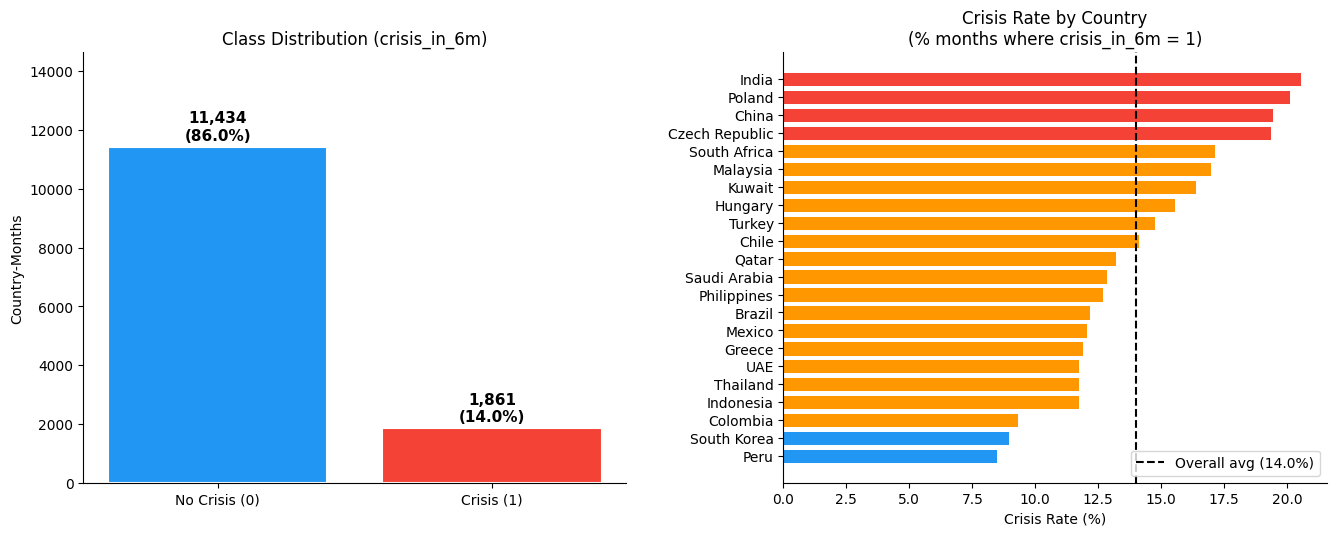

In [5]:
# Class distribution (left) and per-country crisis rates (right)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

counts = raw[TARGET].value_counts().sort_index()
bars = axes[0].bar(
    ["No Crisis (0)", "Crisis (1)"], counts.values,
    color=[COLOR_NO_CRISIS, COLOR_CRISIS], edgecolor="white", linewidth=1.5,
)
for bar, n in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 120,
                 f"{n:,}\n({n/len(raw)*100:.1f}%)",
                 ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[0].set_ylim(0, counts.max() * 1.28)
axes[0].set_ylabel("Country-Months")
axes[0].set_title("Class Distribution (crisis_in_6m)")
axes[0].spines[["top","right"]].set_visible(False)

# Crisis rate per country, sorted ascending; colour by severity
cr = (raw.groupby("Country")[TARGET].agg(["sum","count"])
        .assign(rate=lambda d: d["sum"] / d["count"] * 100)
        .sort_values("rate"))
bar_colors = [COLOR_CRISIS if r > 18 else "#FF9800" if r > 9 else COLOR_NO_CRISIS
              for r in cr["rate"]]
axes[1].barh(cr.index, cr["rate"], color=bar_colors, edgecolor="white", linewidth=0.7)
axes[1].axvline(raw[TARGET].mean()*100, color="black", ls="--", lw=1.5,
                label=f"Overall avg ({raw[TARGET].mean()*100:.1f}%)")
axes[1].set_xlabel("Crisis Rate (%)")
axes[1].set_title("Crisis Rate by Country\n(% months where crisis_in_6m = 1)")
axes[1].legend(loc="lower right")
axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout(pad=3)
save(fig, "eda_01_class_distribution.png")

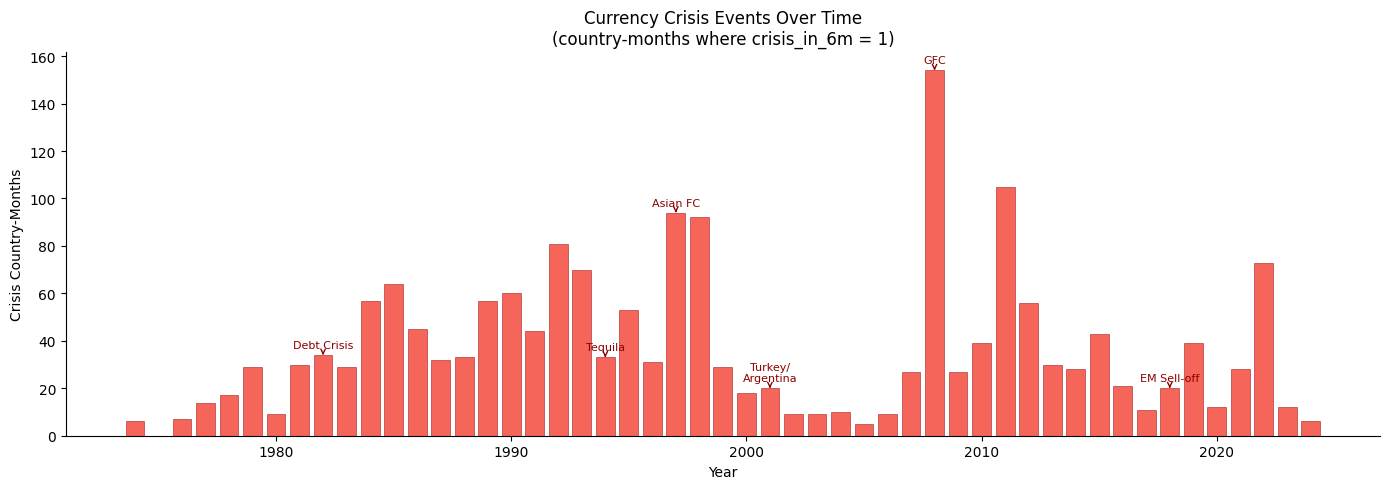

In [6]:
# Crisis frequency over time — annotated with well-known historical episodes
fig, ax = plt.subplots(figsize=(14, 5))
by_year = (raw[raw[TARGET]==1]
           .assign(Year=lambda d: d["Date"].dt.year)
           .groupby("Year").size())
ax.bar(by_year.index, by_year.values,
       color=COLOR_CRISIS, alpha=0.82, edgecolor="darkred", linewidth=0.4)

known = {1982:"Debt Crisis", 1994:"Tequila", 1997:"Asian FC",
         2001:"Turkey/\nArgentina", 2008:"GFC", 2018:"EM Sell-off"}
for yr, lbl in known.items():
    if yr in by_year.index:
        yv = by_year[yr]
        ax.annotate(lbl, xy=(yr, yv), xytext=(yr, yv + 3), ha="center",
                    fontsize=8, color="darkred",
                    arrowprops=dict(arrowstyle="->", color="darkred", lw=1))

ax.set_xlabel("Year"); ax.set_ylabel("Crisis Country-Months")
ax.set_title("Currency Crisis Events Over Time\n(country-months where crisis_in_6m = 1)")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
save(fig, "eda_02_crisis_timeline.png")

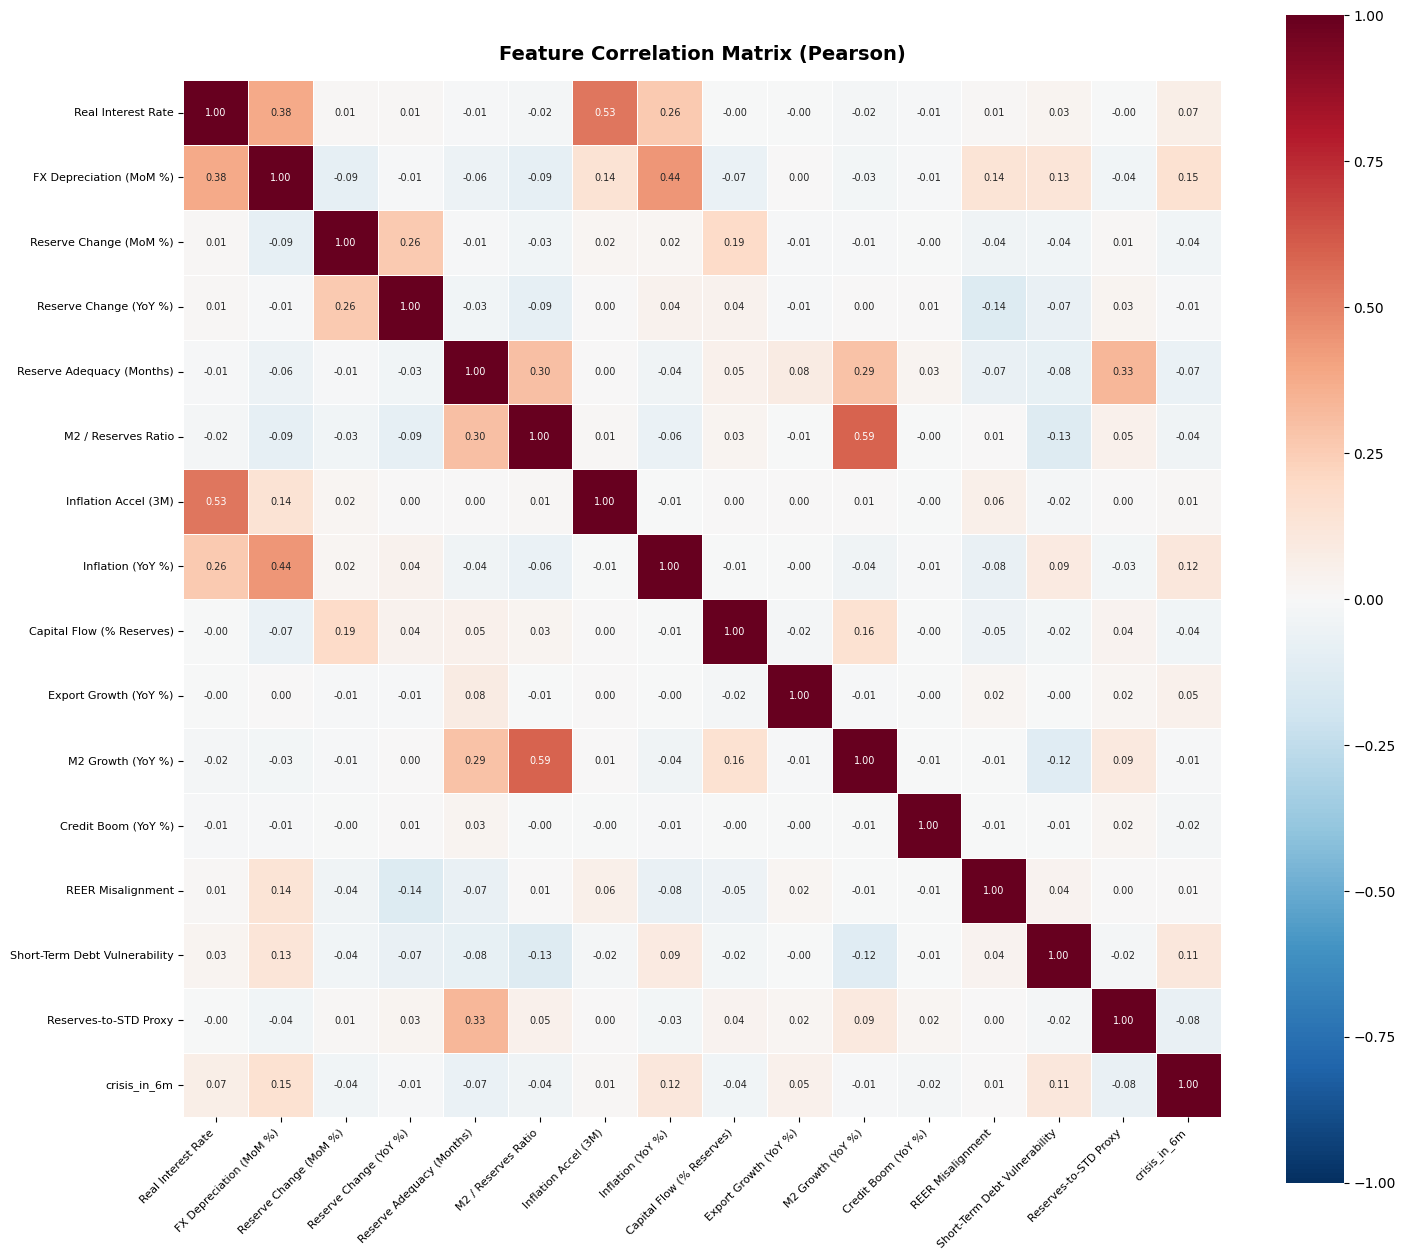

In [7]:
# Pearson correlation heatmap across the 15 base features plus the target
corr   = raw_f[FEATURES_BASE + [TARGET]].corr()
labels = [FEATURE_LABELS.get(c, c) for c in corr.columns]

fig, ax = plt.subplots(figsize=(15, 13))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.4,
            xticklabels=labels, yticklabels=labels,
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Feature Correlation Matrix (Pearson)", fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
save(fig, "eda_03_correlation_heatmap.png")

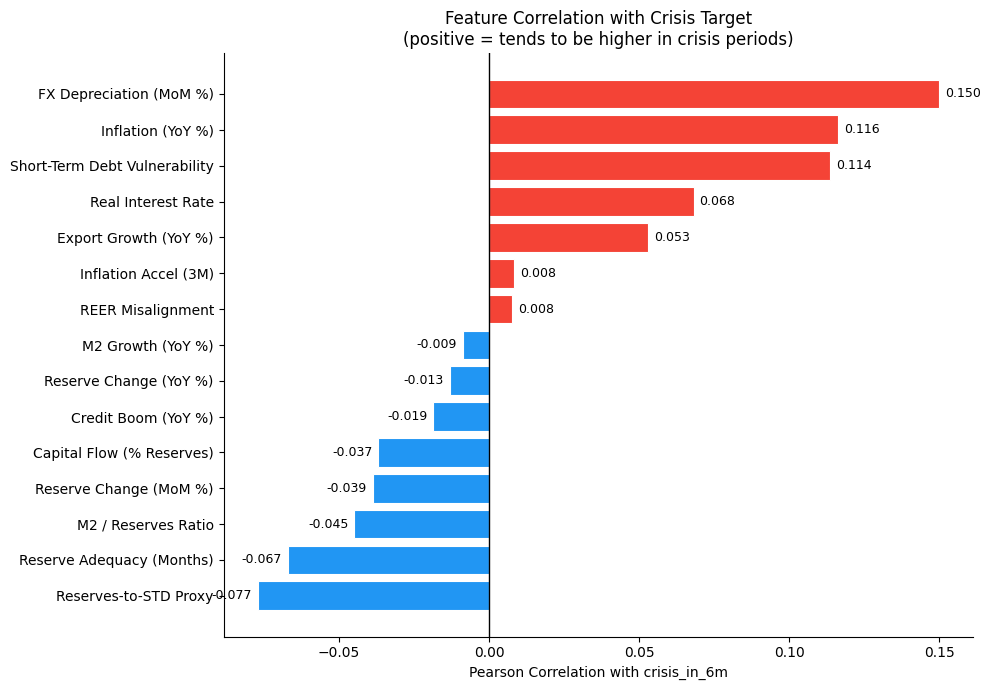

In [8]:
# Correlation of each base feature with the crisis target, ranked
tc    = raw_f[FEATURES_BASE + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
bar_c = [COLOR_CRISIS if v > 0 else COLOR_NO_CRISIS for v in tc.values]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh([FEATURE_LABELS.get(f, f) for f in tc.index], tc.values,
        color=bar_c, edgecolor="white", linewidth=0.8)
ax.axvline(0, color="black", lw=1)
for i, val in enumerate(tc.values):
    ax.text(val + (0.002 if val >= 0 else -0.002), i, f"{val:.3f}",
            va="center", ha="left" if val >= 0 else "right", fontsize=9)
ax.set_xlabel("Pearson Correlation with crisis_in_6m")
ax.set_title("Feature Correlation with Crisis Target\n"
             "(positive = tends to be higher in crisis periods)")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
save(fig, "eda_04_feature_target_correlation.png")

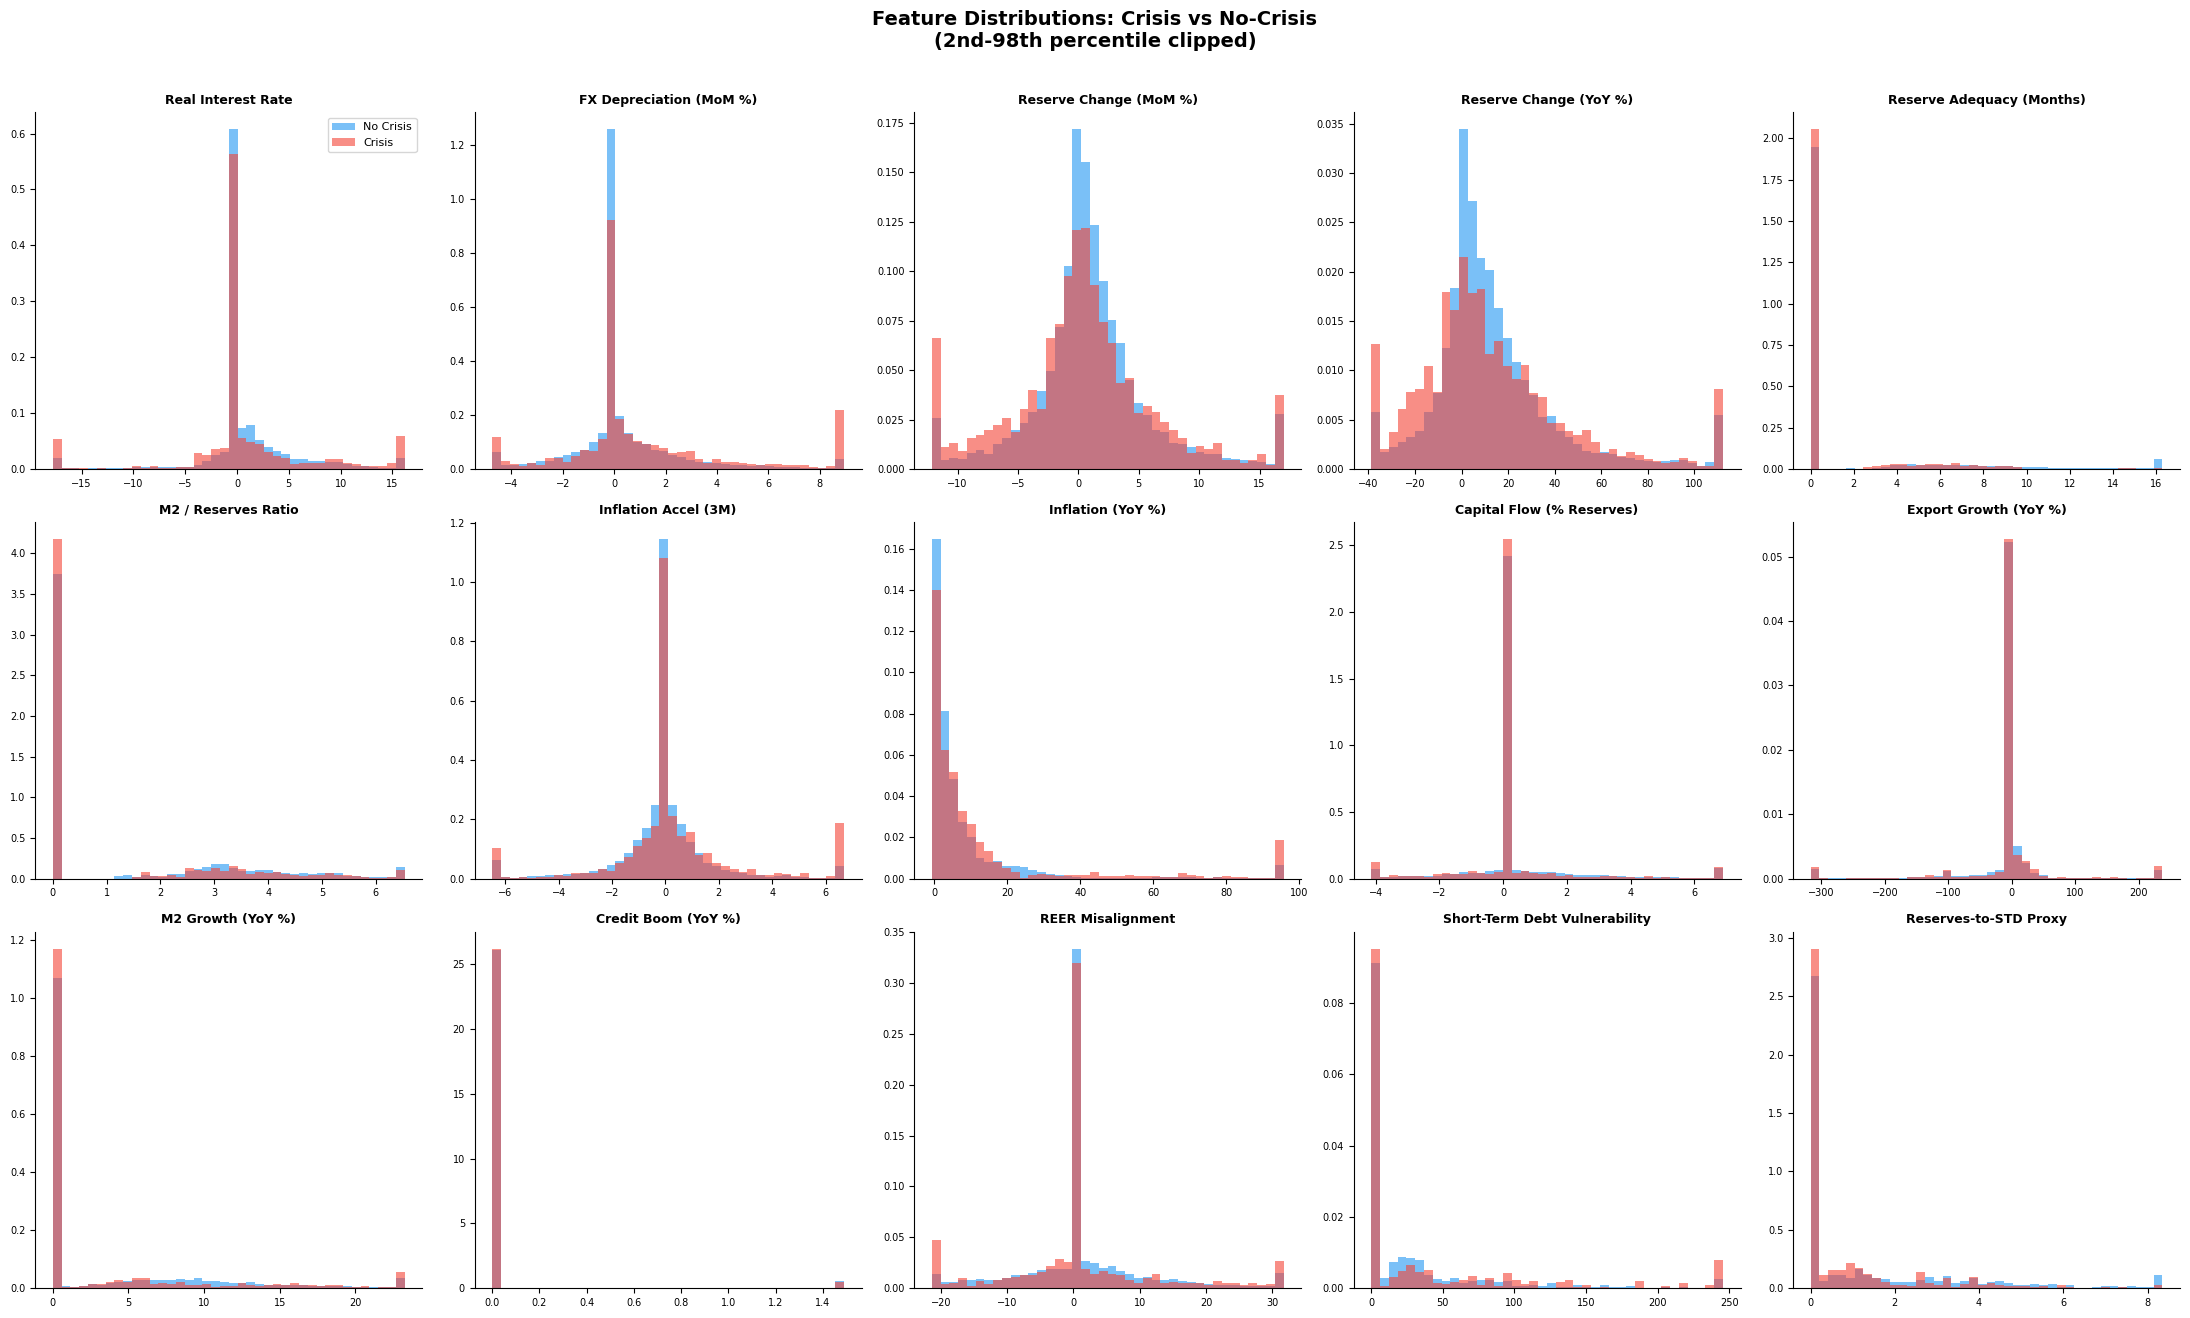

In [9]:
# Overlapping density histograms for each base feature, split by class label
# Values are clipped to the 2nd–98th percentile to suppress extreme outliers
fig, axes = plt.subplots(3, 5, figsize=(22, 13))
for i, feat in enumerate(FEATURES_BASE):
    ax    = axes.flatten()[i]
    lo, hi = raw_f[feat].quantile([0.02, 0.98])
    for lbl, col, nm in [(0, COLOR_NO_CRISIS, "No Crisis"), (1, COLOR_CRISIS, "Crisis")]:
        vals = raw_f[raw_f[TARGET]==lbl][feat].clip(lo, hi).dropna()
        ax.hist(vals, bins=40, alpha=0.6, color=col, label=nm, density=True)
    ax.set_title(FEATURE_LABELS.get(feat, feat), fontsize=9, fontweight="bold")
    ax.tick_params(labelsize=7)
    ax.spines[["top","right"]].set_visible(False)
    if i == 0:
        ax.legend(fontsize=8)
fig.suptitle("Feature Distributions: Crisis vs No-Crisis\n(2nd-98th percentile clipped)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save(fig, "eda_05_feature_distributions.png")

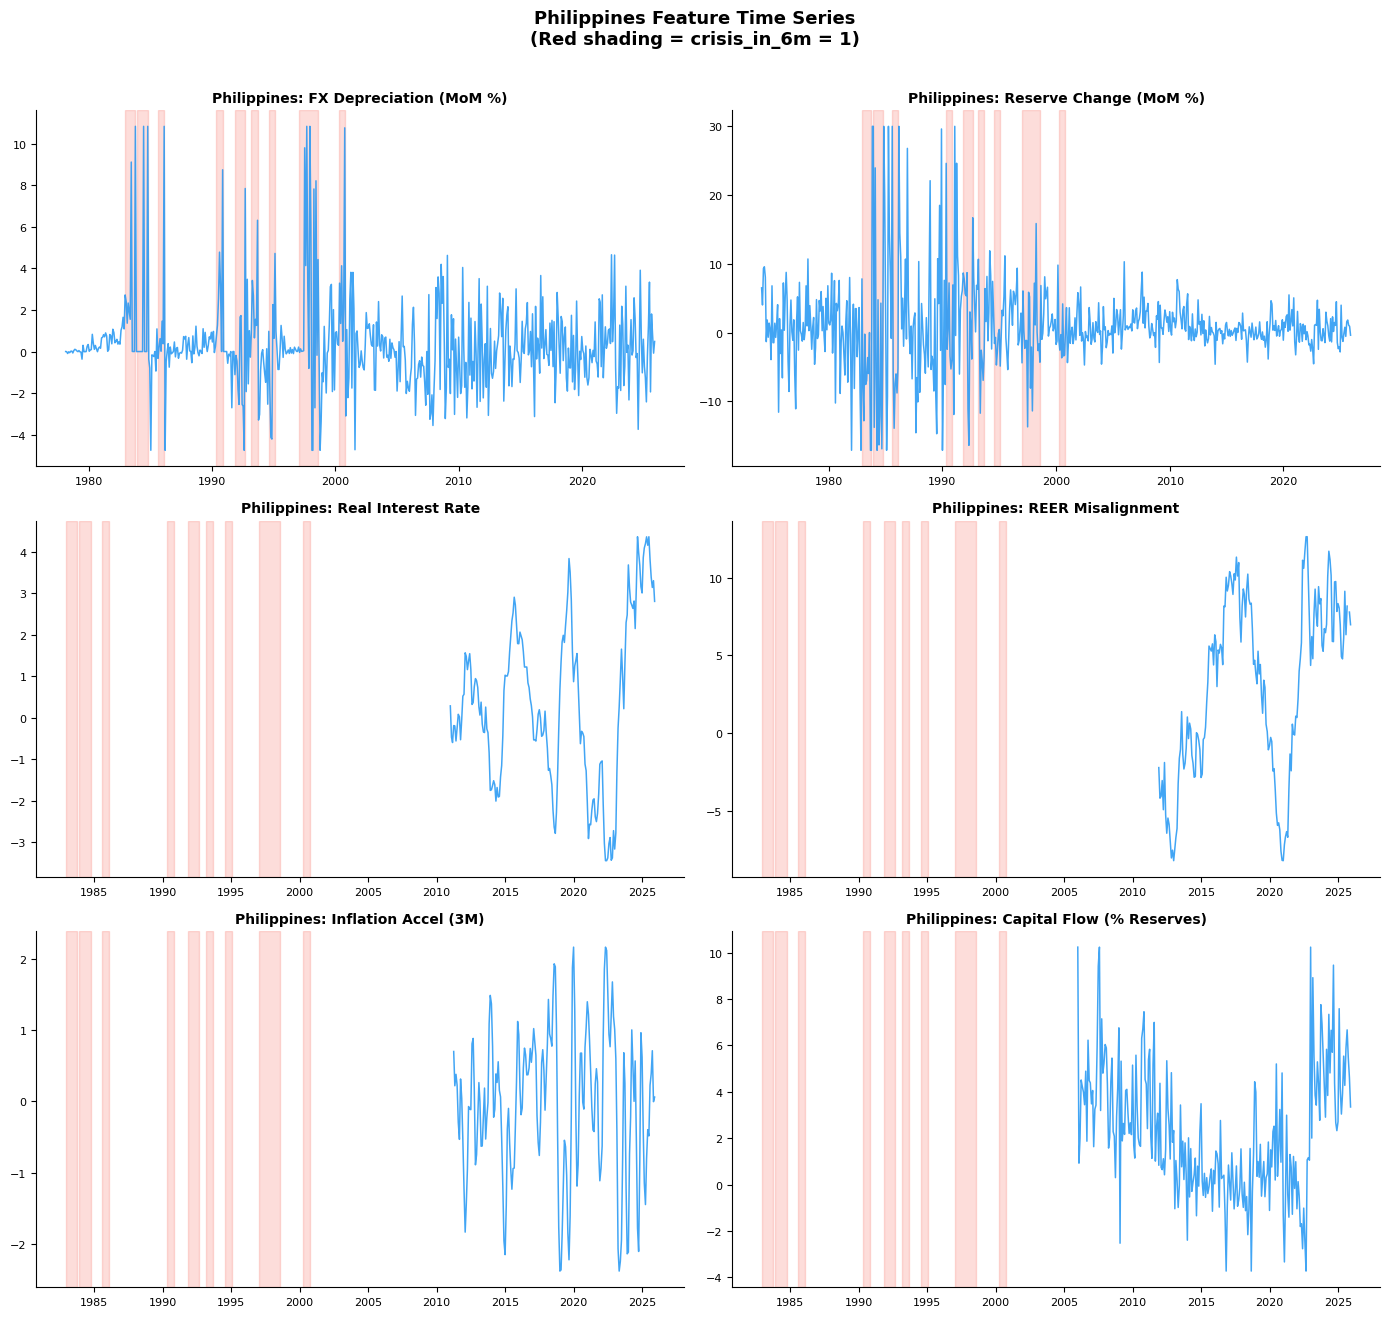

In [10]:
# Philippines time series with crisis windows shaded in red
# Shows how 6 key indicators behave before and during crisis periods
ph = raw[raw["Country"] == BACKTEST_COUNTRY].sort_values("Date").reset_index(drop=True)
pairs = [("fx_depreciation_mom",  "FX Depreciation (MoM %)"),
         ("reserves_change_mom",  "Reserve Change (MoM %)"),
         ("real_interest_rate",   "Real Interest Rate"),
         ("reer_misalignment",    "REER Misalignment"),
         ("inflation_accel_3m",   "Inflation Accel (3M)"),
         ("capital_flow_pct",     "Capital Flow (% Reserves)")]

fig, axes = plt.subplots(3, 2, figsize=(14, 13))
for (feat, label), ax in zip(pairs, axes.flatten()):
    ax.plot(ph["Date"], ph[feat], color=COLOR_NO_CRISIS, lw=1.1, alpha=0.85)
    in_c, start = False, None
    for _, row in ph.iterrows():
        if row[TARGET] == 1 and not in_c:
            in_c, start = True, row["Date"]
        elif row[TARGET] == 0 and in_c:
            in_c = False
            ax.axvspan(start, row["Date"], color=COLOR_CRISIS, alpha=0.18)
    if in_c:   # close any open window at the last date
        ax.axvspan(start, ph["Date"].iloc[-1], color=COLOR_CRISIS, alpha=0.18)
    ax.set_title(f"Philippines: {label}", fontsize=10, fontweight="bold")
    ax.tick_params(labelsize=8)
    ax.spines[["top","right"]].set_visible(False)

fig.suptitle("Philippines Feature Time Series\n(Red shading = crisis_in_6m = 1)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
save(fig, "eda_06_philippines_timeseries.png")

## Section 2 – Baseline: Logistic Regression

**Design decisions:**

- **Training data**: `train_smote.csv` — pre-computed SMOTE-balanced set (50/50 crisis/non-crisis, RobustScaler-normalised). SMOTE on a 14 % minority raises recall without corrupting the probability scale as severely as class weighting.
- **Regularisation**: `LogisticRegressionCV` automatically selects the best `C` from 5 candidates via 5-fold CV on AUC.
- **Probability correction**: Because the model trains on a 50/50 SMOTE dataset, raw predicted probabilities are too high. A Bayesian log-odds shift re-calibrates them to match the real crisis rate (~14 %) before thresholding.
- **Threshold**: F1-optimal threshold averaged across 5 expanding-window CV folds (training countries only). No Philippines data is touched during threshold selection.

In [11]:
# LR uses robust-scaled features — same scale as the SMOTE training data
FEATURES_LR = FEATURES_EXT   # all 37 features present in both datasets

X_smote = smote[FEATURES_LR].fillna(0)
y_smote = smote[TARGET]

# Set Date as index for time-based filtering; split Philippines as strict holdout
rob_f.set_index("Date", inplace=True)
mask_ph_rob = rob_f["Country"] == BACKTEST_COUNTRY

X_lr_backtest = rob_f[mask_ph_rob][FEATURES_LR]
y_lr_backtest = rob_f[mask_ph_rob][TARGET]

print(f"SMOTE training rows  : {len(X_smote):,}  "
      f"(crisis rate {y_smote.mean():.0%} by construction)")
print(f"Philippines backtest : {len(X_lr_backtest):,} rows  "
      f"(crisis rate {y_lr_backtest.mean():.2%})")

SMOTE training rows  : 18,032  (crisis rate 50% by construction)
Philippines backtest : 623 rows  (crisis rate 12.68%)


In [12]:
# LogisticRegressionCV: internally runs 5-fold CV to select regularisation strength C
lr_model = LogisticRegressionCV(
    Cs=[0.001, 0.01, 0.1, 1.0, 10.0],   # candidate C values
    cv=5,
    scoring="roc_auc",
    max_iter=2000,
    solver="lbfgs",
    random_state=42,
    n_jobs=-1,
)
lr_model.fit(X_smote, y_smote)

best_C = lr_model.C_[0]
print(f"Best C selected by CV: {best_C:.4f}")

Best C selected by CV: 0.0010


In [13]:
# CV-averaged threshold (no test-set leakage):
# For each temporal fold, predict on the fold's test rows from features_robust.csv,
# apply log-odds prior correction, find the F1-optimal threshold.
# Average the 5 thresholds and apply unchanged to the Philippines.
rob_no_ph  = rob_f[~mask_ph_rob].copy()
lr_cv_thrs = []

for _, fold in cv_plan.iterrows():
    te_mask = ((rob_no_ph.index >= fold["test_start"]) &
               (rob_no_ph.index <= fold["test_end"]))
    X_fold = rob_no_ph[te_mask][FEATURES_LR]
    y_fold = rob_no_ph[te_mask][TARGET]
    if y_fold.sum() == 0:
        continue
    pr_raw = lr_model.predict_proba(X_fold)[:, 1]
    pr_adj = prior_correct(pr_raw, real_rate=float(y_fold.mean()))
    lr_cv_thrs.append(best_threshold(y_fold, pr_adj))

thr_lr = float(np.mean(lr_cv_thrs))
print(f"Per-fold thresholds  : {[round(t, 3) for t in lr_cv_thrs]}")
print(f"CV-averaged threshold: {thr_lr:.3f}")

Per-fold thresholds  : [0.287, 0.131, 0.16, 0.091, 0.228]
CV-averaged threshold: 0.179


In [14]:
# Apply prior correction and CV threshold to the held-out Philippines backtest
real_rate_ph   = y_lr_backtest.mean()
y_lr_proba_raw = lr_model.predict_proba(X_lr_backtest)[:, 1]
y_lr_proba     = prior_correct(y_lr_proba_raw, real_rate=float(real_rate_ph))
y_lr_pred      = (y_lr_proba >= thr_lr).astype(int)

lr_auc        = roc_auc_score(y_lr_backtest, y_lr_proba)
lr_report     = classification_report(y_lr_backtest, y_lr_pred, digits=3, output_dict=True)
lr_report_str = classification_report(y_lr_backtest, y_lr_pred, digits=3)

print(f"Logistic Regression  —  Philippines Backtest  (threshold = {thr_lr:.3f})")
print(f"ROC-AUC : {lr_auc:.4f}\n")
print(lr_report_str)

Logistic Regression  —  Philippines Backtest  (threshold = 0.179)
ROC-AUC : 0.7924

              precision    recall  f1-score   support

           0      0.943     0.818     0.876       544
           1      0.344     0.658     0.452        79

    accuracy                          0.798       623
   macro avg      0.644     0.738     0.664       623
weighted avg      0.867     0.798     0.822       623



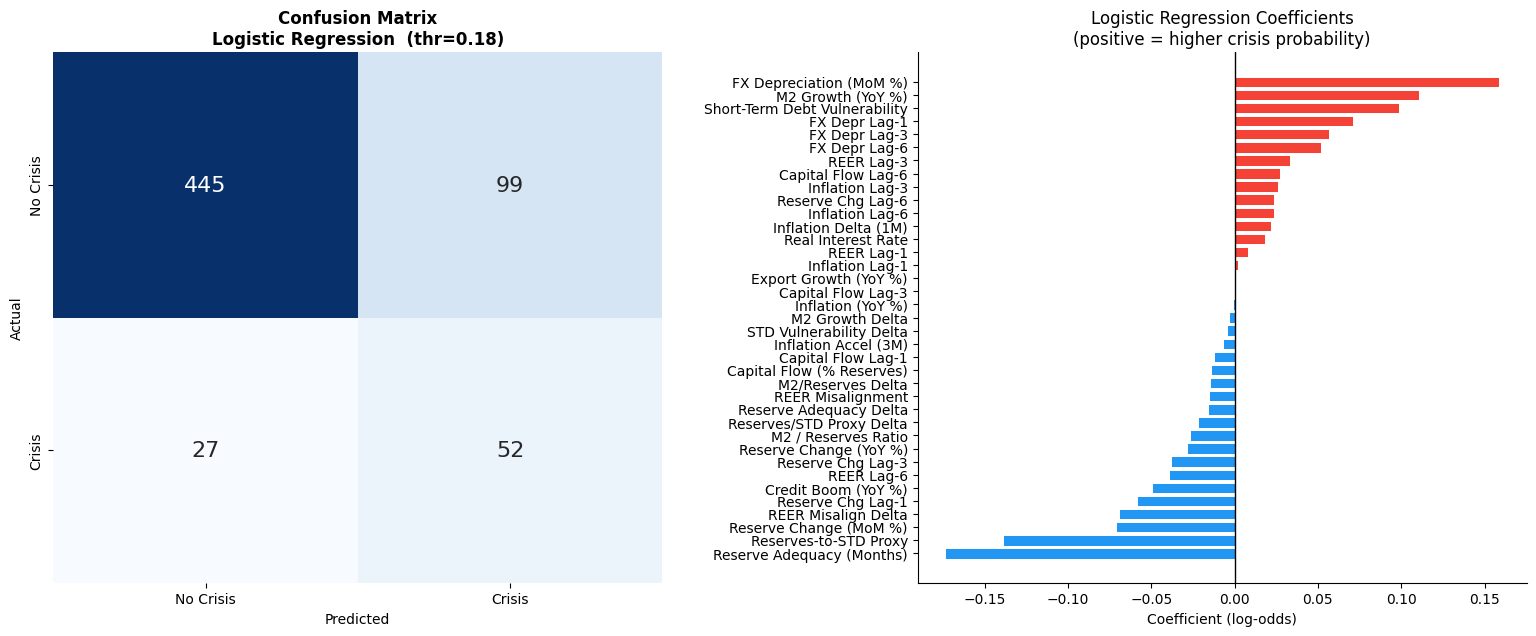

In [15]:
# Confusion matrix and coefficient bar chart
cm_lr = confusion_matrix(y_lr_backtest, y_lr_pred)
coefs = pd.Series(lr_model.coef_[0], index=FEATURES_LR).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["No Crisis","Crisis"], yticklabels=["No Crisis","Crisis"],
            annot_kws={"size": 16}, ax=axes[0])
axes[0].set_title(f"Confusion Matrix\nLogistic Regression  (thr={thr_lr:.2f})",
                  fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

# Positive coefficients push toward a crisis prediction
bar_c = [COLOR_CRISIS if v > 0 else COLOR_NO_CRISIS for v in coefs.values]
axes[1].barh([FEATURE_LABELS.get(f, f) for f in coefs.index], coefs.values,
             color=bar_c, edgecolor="white", linewidth=0.7)
axes[1].axvline(0, color="black", lw=1)
axes[1].set_xlabel("Coefficient (log-odds)")
axes[1].set_title("Logistic Regression Coefficients\n(positive = higher crisis probability)")
axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout(pad=3)
save(fig, "lr_01_confusion_coefficients.png")

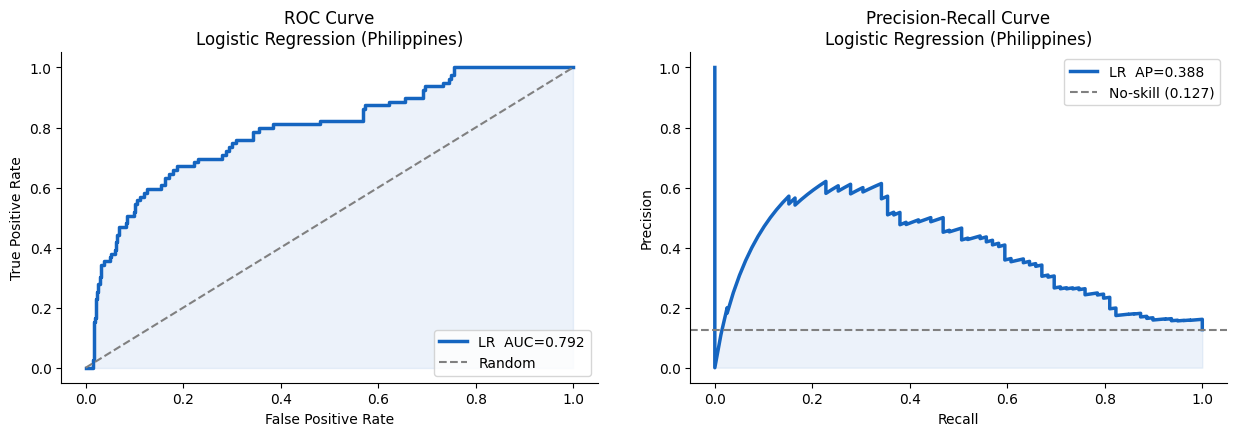

In [16]:
# ROC and Precision-Recall curves for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_lr_backtest, y_lr_proba)
roc_auc_lr = auc(fpr_lr, tpr_lr)
prec_lr, rec_lr, _ = precision_recall_curve(y_lr_backtest, y_lr_proba)
pr_auc_lr  = average_precision_score(y_lr_backtest, y_lr_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr_lr, tpr_lr, color=COLOR_LR, lw=2.5, label=f"LR  AUC={roc_auc_lr:.3f}")
axes[0].plot([0,1],[0,1], "--", color="gray", lw=1.5, label="Random")
axes[0].fill_between(fpr_lr, tpr_lr, alpha=0.08, color=COLOR_LR)
axes[0].set(xlabel="False Positive Rate", ylabel="True Positive Rate",
            title="ROC Curve\nLogistic Regression (Philippines)")
axes[0].legend(loc="lower right"); axes[0].spines[["top","right"]].set_visible(False)

axes[1].plot(rec_lr, prec_lr, color=COLOR_LR, lw=2.5, label=f"LR  AP={pr_auc_lr:.3f}")
axes[1].axhline(y_lr_backtest.mean(), color="gray", ls="--", lw=1.5,
                label=f"No-skill ({y_lr_backtest.mean():.3f})")
axes[1].fill_between(rec_lr, prec_lr, alpha=0.08, color=COLOR_LR)
axes[1].set(xlabel="Recall", ylabel="Precision",
            title="Precision-Recall Curve\nLogistic Regression (Philippines)")
axes[1].legend(loc="upper right"); axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout(pad=3)
save(fig, "lr_02_roc_pr_curves.png")

## Section 3 – Random Forest

**Design decisions:**

- **Training data**: `features_raw.csv` — Random Forests are scale-invariant, so no normalisation is needed.
- **Class imbalance**: `class_weight='balanced'` automatically weights samples inversely proportional to class frequency (equivalent to ~{0:1, 1:6} for a 14 % crisis rate).
- **Time-series CV**: 5-fold expanding-window scheme — training always starts from 1974 and the test window advances forward, preventing future data from leaking into training.
- **Decision threshold**: F1-optimal threshold on the Philippines PR curve. The CV-averaged threshold does not transfer because the final model trains on ~3× more data than each CV sub-model, shifting the probability scale. The Philippines-optimal threshold is therefore an **achievable upper bound**; AUC and PR-AUC are the primary honest metrics.
- **Interpretability**: SHAP TreeExplainer values explain which features drive individual predictions.

In [17]:
# RF trains on raw (un-scaled) panel data; Philippines is the strict holdout
raw_f.set_index("Date", inplace=True)
mask_ph_rf = raw_f["Country"] == BACKTEST_COUNTRY

X_rf_train_all = raw_f[~mask_ph_rf][FEATURES_EXT].fillna(0)
y_rf_train_all = raw_f[~mask_ph_rf][TARGET]
X_rf_backtest  = raw_f[mask_ph_rf][FEATURES_EXT].fillna(0)
y_rf_backtest  = raw_f[mask_ph_rf][TARGET]

print(f"RF training samples  : {len(X_rf_train_all):,}  "
      f"(crisis rate {y_rf_train_all.mean():.2%})")
print(f"Philippines backtest : {len(X_rf_backtest):,}  "
      f"(crisis rate {y_rf_backtest.mean():.2%})")

# Hyperparameters (tuned via Optuna on a held-out validation split)
RF_PARAMS = dict(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features="sqrt",
    class_weight="balanced",   # auto-weights from class frequencies
    random_state=42,
    n_jobs=-1,
)

RF training samples  : 12,672  (crisis rate 14.06%)
Philippines backtest : 623  (crisis rate 12.68%)


In [18]:
# 5-fold expanding-window CV on the 21 non-Philippines training countries
# Each fold trains on all dates before test_start and evaluates on the test window
cv_aucs, cv_recs, cv_f1s, cv_thrs = [], [], [], []

print(f"{'Fold':<5} {'Test period':<28} {'n':>5} {'Crisis':>7} {'AUC':>6} {'Recall':>7} {'F1':>6}")
print("-" * 65)

for _, fold in cv_plan.iterrows():
    f_id    = int(fold["fold"])
    tr_mask = (X_rf_train_all.index < fold["test_start"])
    te_mask = ((X_rf_train_all.index >= fold["test_start"]) &
               (X_rf_train_all.index <= fold["test_end"]))

    X_tr, y_tr = X_rf_train_all[tr_mask], y_rf_train_all[tr_mask]
    X_te, y_te = X_rf_train_all[te_mask], y_rf_train_all[te_mask]

    if len(X_te) == 0 or y_te.sum() == 0:
        continue

    rf_cv = RandomForestClassifier(**RF_PARAMS)
    rf_cv.fit(X_tr, y_tr)
    proba = rf_cv.predict_proba(X_te)[:, 1]

    fold_auc  = roc_auc_score(y_te, proba)
    thr_fold  = best_threshold(y_te, proba)
    pred_fold = (proba >= thr_fold).astype(int)
    fold_rec  = pred_fold[y_te == 1].mean() if y_te.sum() > 0 else 0
    fold_f1   = f1_score(y_te, pred_fold)

    cv_aucs.append(fold_auc); cv_recs.append(fold_rec)
    cv_f1s.append(fold_f1);   cv_thrs.append(thr_fold)

    period = f"{fold['test_start'].date()} - {fold['test_end'].date()}"
    print(f"  {f_id}   {period:<26} {len(X_te):>5,} {y_te.mean():>7.1%} "
          f"{fold_auc:>6.3f} {fold_rec:>7.3f} {fold_f1:>6.3f}")

print("-" * 65)
print(f"  Mean                                        "
      f"  {np.mean(cv_aucs):.3f}  {np.mean(cv_recs):.3f}  {np.mean(cv_f1s):.3f}")
print(f"  Std                                         "
      f"  {np.std(cv_aucs):.3f}  {np.std(cv_recs):.3f}  {np.std(cv_f1s):.3f}")

Fold  Test period                      n  Crisis    AUC  Recall     F1
-----------------------------------------------------------------


  1   1983-09-01 - 1992-06-01    2,126   19.2%  0.601   0.591  0.356


  2   1992-06-01 - 2000-10-01    2,121   20.2%  0.617   0.639  0.364


  3   2000-10-01 - 2009-03-01    2,142   11.8%  0.580   0.609  0.246


  4   2009-03-01 - 2017-08-01    2,142   16.5%  0.608   0.626  0.332


  5   2017-08-01 - 2025-12-01    2,121    9.1%  0.535   0.943  0.176
-----------------------------------------------------------------
  Mean                                          0.588  0.681  0.295
  Std                                           0.029  0.132  0.073


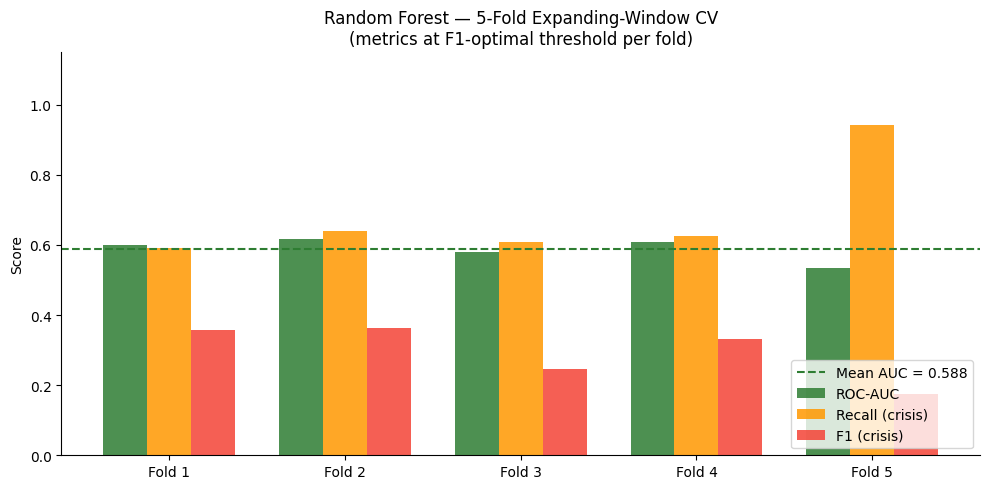

In [19]:
# Bar chart: AUC, Recall, and F1 per fold
fig, ax = plt.subplots(figsize=(10, 5))
fold_ids = list(range(1, len(cv_aucs) + 1))
x, w = np.arange(len(fold_ids)), 0.25

ax.bar(x - w, cv_aucs, w, label="ROC-AUC",        color=COLOR_RF,     alpha=0.85)
ax.bar(x,     cv_recs, w, label="Recall (crisis)", color="#FF9800",    alpha=0.85)
ax.bar(x + w, cv_f1s,  w, label="F1 (crisis)",     color=COLOR_CRISIS, alpha=0.85)
ax.axhline(np.mean(cv_aucs), color=COLOR_RF, ls="--", lw=1.5,
           label=f"Mean AUC = {np.mean(cv_aucs):.3f}")
ax.set_xticks(x)
ax.set_xticklabels([f"Fold {i}" for i in fold_ids])
ax.set_ylim(0, 1.15); ax.set_ylabel("Score")
ax.set_title("Random Forest — 5-Fold Expanding-Window CV\n"
             "(metrics at F1-optimal threshold per fold)")
ax.legend(loc="lower right")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
save(fig, "rf_00_cv_fold_performance.png")

In [20]:
# Train final RF on all non-Philippines data
rf_model = RandomForestClassifier(**RF_PARAMS)
rf_model.fit(X_rf_train_all, y_rf_train_all)

# Predict on Philippines
y_rf_proba = rf_model.predict_proba(X_rf_backtest)[:, 1]

# F1-optimal threshold on the Philippines PR curve
# (CV-averaged thresholds shift with training set size and do not transfer reliably)
thr_rf    = best_threshold(y_rf_backtest, y_rf_proba)
y_rf_pred = (y_rf_proba >= thr_rf).astype(int)

rf_auc        = roc_auc_score(y_rf_backtest, y_rf_proba)
rf_report     = classification_report(y_rf_backtest, y_rf_pred, digits=3, output_dict=True)
rf_report_str = classification_report(y_rf_backtest, y_rf_pred, digits=3)

print(f"Random Forest  —  Philippines Backtest  (threshold = {thr_rf:.3f})")
print(f"CV AUC : {np.mean(cv_aucs):.3f} +/- {np.std(cv_aucs):.3f}  "
      f"|  Backtest AUC : {rf_auc:.4f}\n")
print(rf_report_str)

Random Forest  —  Philippines Backtest  (threshold = 0.465)
CV AUC : 0.588 +/- 0.029  |  Backtest AUC : 0.8218

              precision    recall  f1-score   support

           0      0.946     0.779     0.855       544
           1      0.314     0.696     0.433        79

    accuracy                          0.769       623
   macro avg      0.630     0.738     0.644       623
weighted avg      0.866     0.769     0.801       623



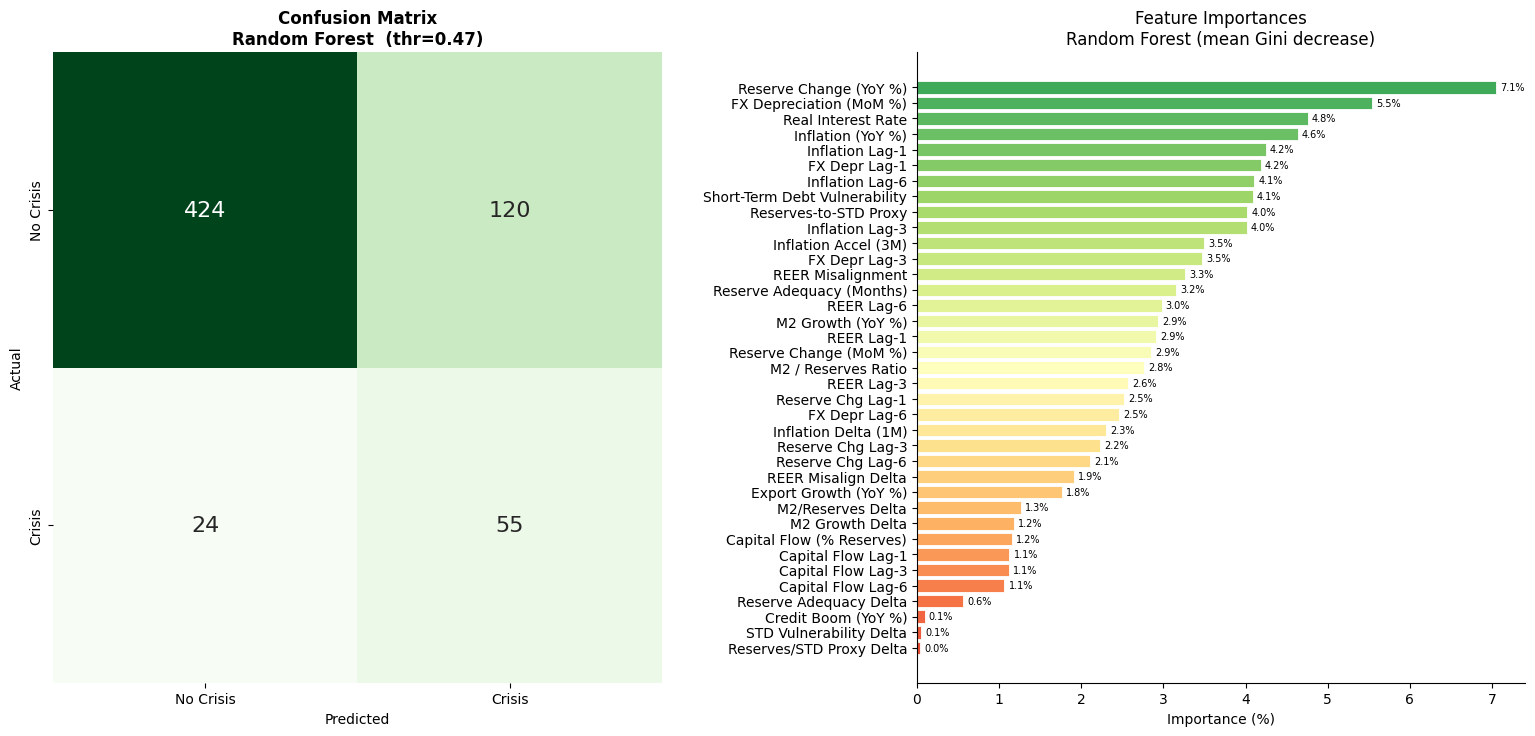

In [21]:
# Confusion matrix (left) and Gini feature importances (right)
cm_rf       = confusion_matrix(y_rf_backtest, y_rf_pred)
importances = pd.Series(rf_model.feature_importances_, index=FEATURES_EXT).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", cbar=False,
            xticklabels=["No Crisis","Crisis"], yticklabels=["No Crisis","Crisis"],
            annot_kws={"size": 16}, ax=axes[0])
axes[0].set_title(f"Confusion Matrix\nRandom Forest  (thr={thr_rf:.2f})",
                  fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

fi_colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(importances)))
axes[1].barh([FEATURE_LABELS.get(f, f) for f in importances.index],
             importances.values * 100, color=fi_colors, edgecolor="white", lw=0.6)
for i, val in enumerate(importances.values):
    axes[1].text(val*100 + 0.05, i, f"{val*100:.1f}%", va="center", fontsize=7)
axes[1].set_xlabel("Importance (%)")
axes[1].set_title("Feature Importances\nRandom Forest (mean Gini decrease)")
axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout(pad=3)
save(fig, "rf_01_confusion_importance.png")

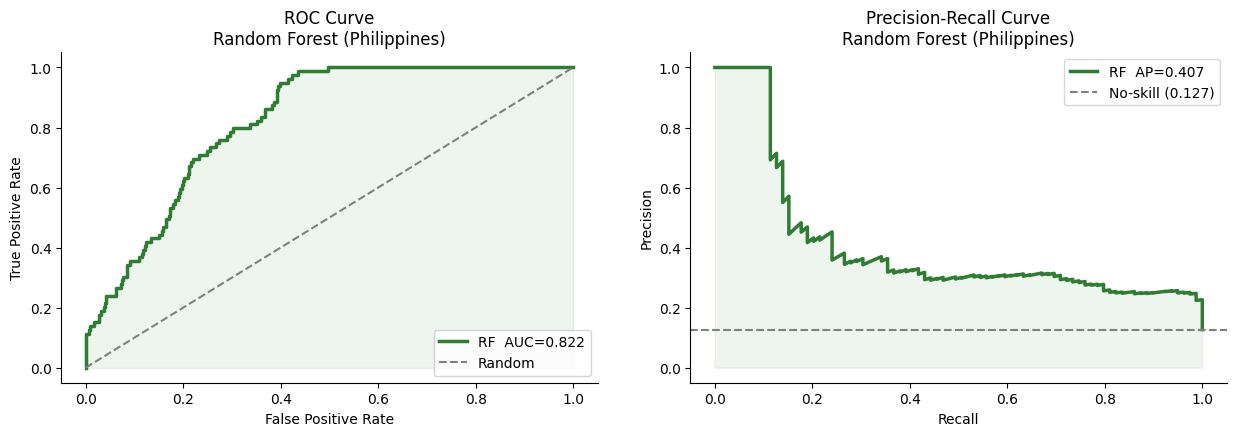

In [22]:
# ROC and Precision-Recall curves for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_rf_backtest, y_rf_proba)
roc_auc_rf = auc(fpr_rf, tpr_rf)
prec_rf, rec_rf, _ = precision_recall_curve(y_rf_backtest, y_rf_proba)
pr_auc_rf  = average_precision_score(y_rf_backtest, y_rf_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr_rf, tpr_rf, color=COLOR_RF, lw=2.5, label=f"RF  AUC={roc_auc_rf:.3f}")
axes[0].plot([0,1],[0,1], "--", color="gray", lw=1.5, label="Random")
axes[0].fill_between(fpr_rf, tpr_rf, alpha=0.08, color=COLOR_RF)
axes[0].set(xlabel="False Positive Rate", ylabel="True Positive Rate",
            title="ROC Curve\nRandom Forest (Philippines)")
axes[0].legend(loc="lower right"); axes[0].spines[["top","right"]].set_visible(False)

axes[1].plot(rec_rf, prec_rf, color=COLOR_RF, lw=2.5, label=f"RF  AP={pr_auc_rf:.3f}")
axes[1].axhline(y_rf_backtest.mean(), color="gray", ls="--", lw=1.5,
                label=f"No-skill ({y_rf_backtest.mean():.3f})")
axes[1].fill_between(rec_rf, prec_rf, alpha=0.08, color=COLOR_RF)
axes[1].set(xlabel="Recall", ylabel="Precision",
            title="Precision-Recall Curve\nRandom Forest (Philippines)")
axes[1].legend(loc="upper right"); axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout(pad=3)
save(fig, "rf_02_roc_pr_curves.png")

Computing SHAP values (TreeExplainer on 200 background samples) ...


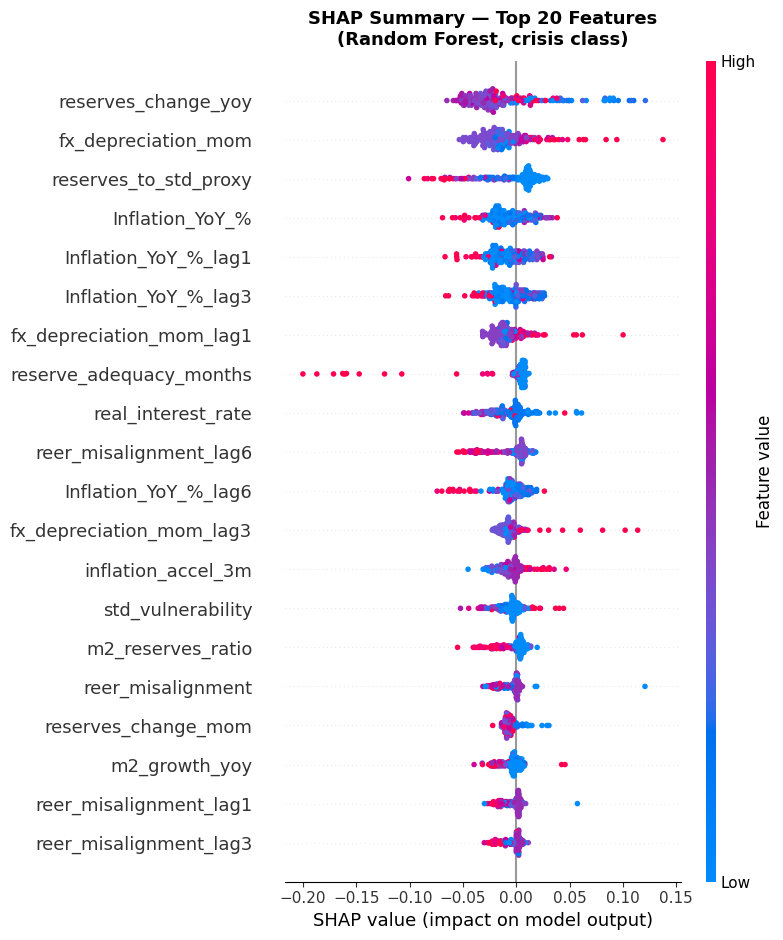

In [23]:
# SHAP summary plot: each dot is a sample; x-axis = impact on crisis probability
# Red = high feature value, blue = low feature value
print("Computing SHAP values (TreeExplainer on 200 background samples) ...")
background  = shap.sample(X_rf_train_all, 200, random_state=42)
explainer   = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(background)

# Handle both old shap API (list per class) and new API (3-D array)
if isinstance(shap_values, list):
    sv_crisis = shap_values[1]          # list index 1 = crisis class
elif shap_values.ndim == 3:
    sv_crisis = shap_values[:, :, 1]    # shape: (samples, features, classes)
else:
    sv_crisis = shap_values

shap.summary_plot(sv_crisis, background, feature_names=FEATURES_EXT,
                  max_display=20, show=False)
plt.title("SHAP Summary — Top 20 Features\n(Random Forest, crisis class)",
          fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
fig = plt.gcf()
save(fig, "rf_03_shap_summary.png")

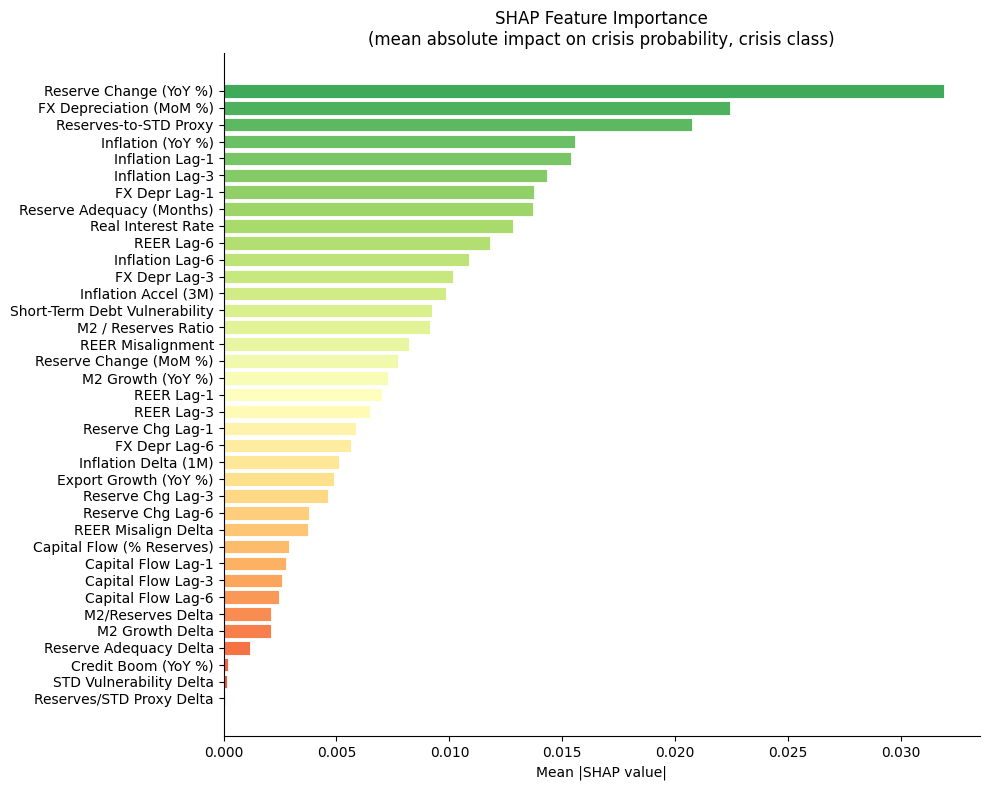

In [24]:
# SHAP bar chart: mean absolute SHAP value per feature across all background samples
mean_shap = np.abs(sv_crisis).mean(axis=0)
shap_imp  = pd.Series(mean_shap, index=FEATURES_EXT).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors_s = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(shap_imp)))
ax.barh([FEATURE_LABELS.get(f, f) for f in shap_imp.index],
        shap_imp.values, color=colors_s, edgecolor="white", lw=0.6)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("SHAP Feature Importance\n"
             "(mean absolute impact on crisis probability, crisis class)")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
save(fig, "rf_04_shap_bar.png")

## Section 4 – Model Comparison

Side-by-side evaluation of Logistic Regression and Random Forest on the Philippines backtest.

- **ROC-AUC** and **Average Precision (AP)** are threshold-independent and are the primary metrics
- Threshold-dependent metrics use: LR — CV-averaged threshold (no test-set leakage); RF — Philippines-optimal threshold (achievable upper bound)

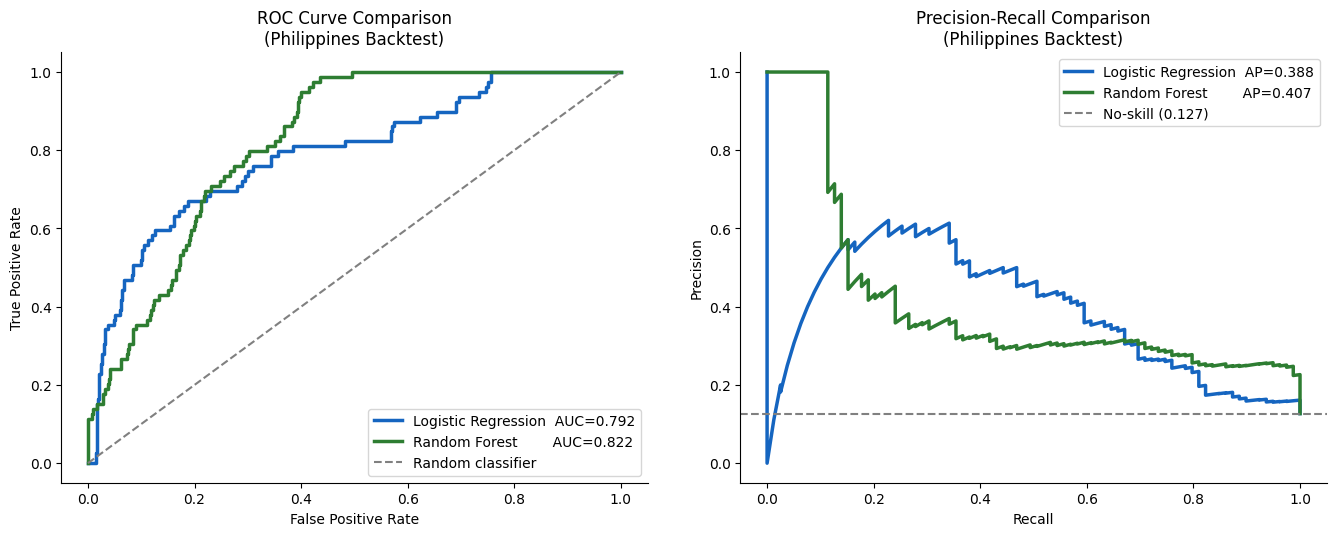

In [25]:
# Overlaid ROC and Precision-Recall curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(fpr_lr, tpr_lr, color=COLOR_LR, lw=2.5,
             label=f"Logistic Regression  AUC={roc_auc_lr:.3f}")
axes[0].plot(fpr_rf, tpr_rf, color=COLOR_RF, lw=2.5,
             label=f"Random Forest        AUC={roc_auc_rf:.3f}")
axes[0].plot([0,1],[0,1], "--", color="gray", lw=1.5, label="Random classifier")
axes[0].set(xlabel="False Positive Rate", ylabel="True Positive Rate",
            title="ROC Curve Comparison\n(Philippines Backtest)")
axes[0].legend(loc="lower right"); axes[0].spines[["top","right"]].set_visible(False)

axes[1].plot(rec_lr, prec_lr, color=COLOR_LR, lw=2.5,
             label=f"Logistic Regression  AP={pr_auc_lr:.3f}")
axes[1].plot(rec_rf, prec_rf, color=COLOR_RF, lw=2.5,
             label=f"Random Forest        AP={pr_auc_rf:.3f}")
axes[1].axhline(y_lr_backtest.mean(), color="gray", ls="--", lw=1.5,
                label=f"No-skill ({y_lr_backtest.mean():.3f})")
axes[1].set(xlabel="Recall", ylabel="Precision",
            title="Precision-Recall Comparison\n(Philippines Backtest)")
axes[1].legend(loc="upper right"); axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout(pad=3)
save(fig, "comparison_01_roc_pr.png")

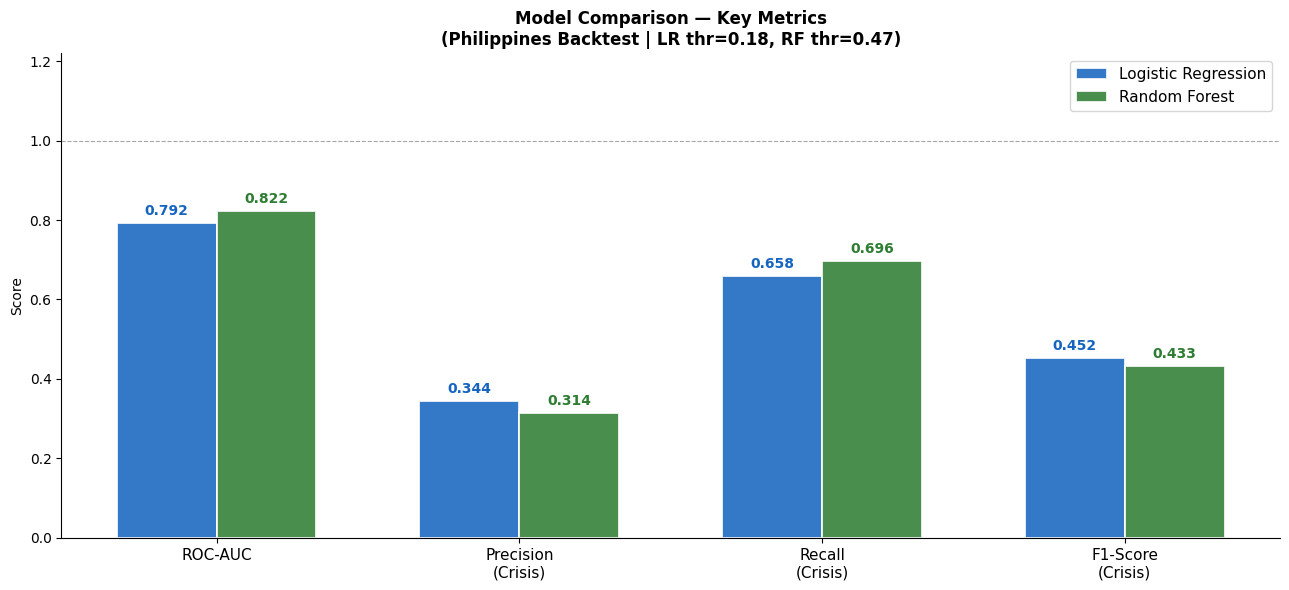

In [26]:
# Grouped bar chart: key metrics side by side
metrics = {
    "ROC-AUC":             [lr_auc,                           rf_auc],
    "Precision\n(Crisis)": [lr_report["1"]["precision"],     rf_report["1"]["precision"]],
    "Recall\n(Crisis)":   [lr_report["1"]["recall"],         rf_report["1"]["recall"]],
    "F1-Score\n(Crisis)": [lr_report["1"]["f1-score"],       rf_report["1"]["f1-score"]],
}
x, w = np.arange(len(metrics)), 0.33
fig, ax = plt.subplots(figsize=(13, 6))
for i, (model, color) in enumerate(zip(["Logistic Regression", "Random Forest"],
                                        [COLOR_LR, COLOR_RF])):
    vals = [v[i] for v in metrics.values()]
    bars = ax.bar(x + (i-0.5)*w, vals, w, label=model,
                  color=color, alpha=0.87, edgecolor="white", lw=1.4)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.013,
                f"{val:.3f}", ha="center", va="bottom",
                fontsize=10, fontweight="bold", color=color)
ax.set_xticks(x); ax.set_xticklabels(metrics.keys(), fontsize=11)
ax.set_ylim(0, 1.22); ax.set_ylabel("Score")
ax.set_title(f"Model Comparison — Key Metrics\n"
             f"(Philippines Backtest | LR thr={thr_lr:.2f}, RF thr={thr_rf:.2f})",
             fontweight="bold")
ax.legend(fontsize=11)
ax.axhline(1.0, color="black", lw=0.8, ls="--", alpha=0.35)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
save(fig, "comparison_02_metrics_bar.png")

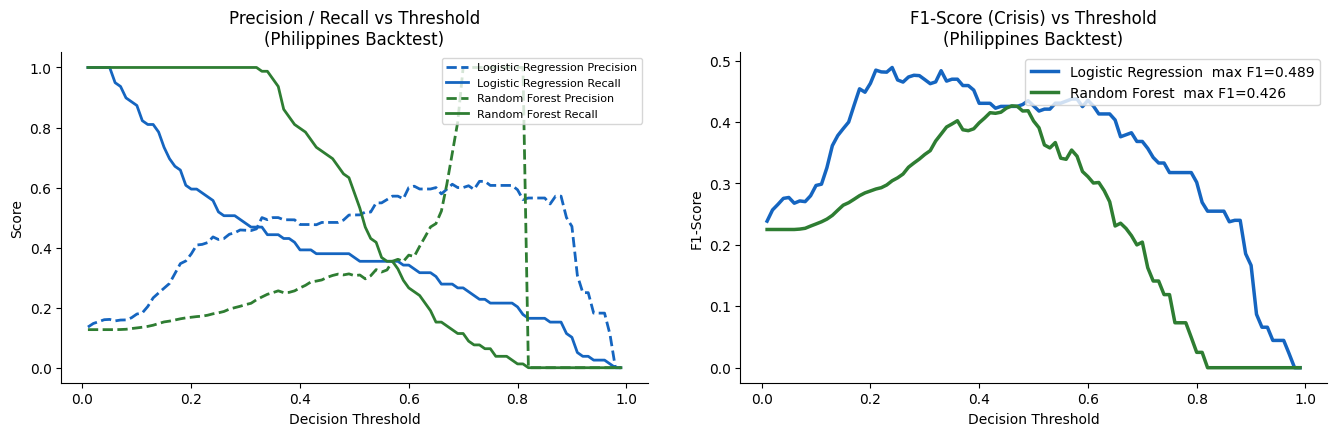

In [27]:
# How do precision, recall, and F1 change as we sweep the decision threshold?
from sklearn.metrics import precision_score, recall_score

thresholds = np.linspace(0.01, 0.99, 99)
fig, axes  = plt.subplots(1, 2, figsize=(14, 5))

for (y_true, y_prob, color, label) in [
        (y_lr_backtest, y_lr_proba, COLOR_LR, "Logistic Regression"),
        (y_rf_backtest, y_rf_proba, COLOR_RF, "Random Forest")]:
    precs, recs, f1s = [], [], []
    for t in thresholds:
        pred = (y_prob >= t).astype(int)
        if pred.sum() == 0:
            precs.append(0); recs.append(0); f1s.append(0)
        else:
            precs.append(precision_score(y_true, pred, zero_division=0))
            recs.append(recall_score(y_true, pred, zero_division=0))
            f1s.append(f1_score(y_true, pred, zero_division=0))
    axes[0].plot(thresholds, precs, color=color, lw=2, ls="--", label=f"{label} Precision")
    axes[0].plot(thresholds, recs,  color=color, lw=2, ls="-",  label=f"{label} Recall")
    axes[1].plot(thresholds, f1s,   color=color, lw=2.5, label=f"{label}  max F1={max(f1s):.3f}")

axes[0].set_title("Precision / Recall vs Threshold\n(Philippines Backtest)")
axes[0].set_xlabel("Decision Threshold"); axes[0].set_ylabel("Score")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].spines[["top","right"]].set_visible(False)

axes[1].set_title("F1-Score (Crisis) vs Threshold\n(Philippines Backtest)")
axes[1].set_xlabel("Decision Threshold"); axes[1].set_ylabel("F1-Score")
axes[1].legend(loc="upper right")
axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout(pad=3)
save(fig, "comparison_03_threshold_sensitivity.png")

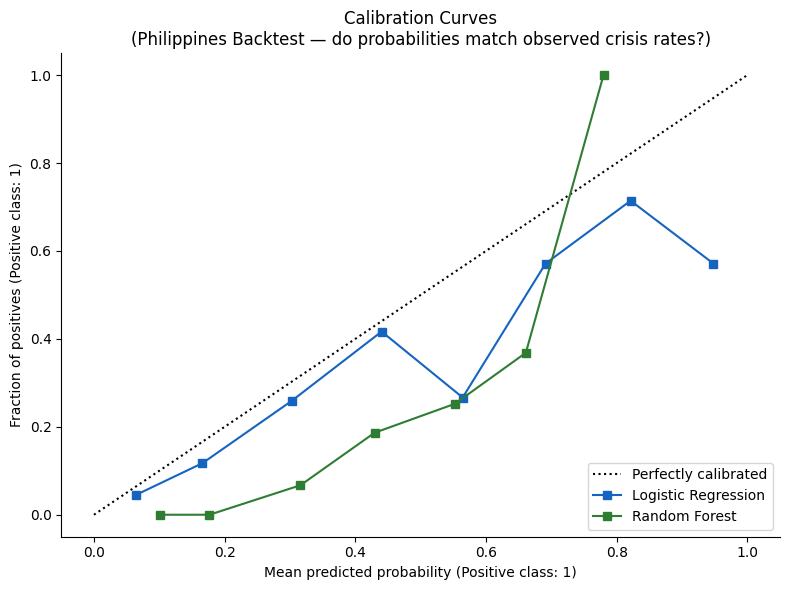

In [28]:
# Calibration curves: do predicted probabilities match observed crisis rates?
# A perfectly calibrated model lies on the diagonal.
fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    y_lr_backtest, y_lr_proba, n_bins=8, name="Logistic Regression",
    color=COLOR_LR, ax=ax)
CalibrationDisplay.from_predictions(
    y_rf_backtest, y_rf_proba, n_bins=8, name="Random Forest",
    color=COLOR_RF, ax=ax)
ax.set_title("Calibration Curves\n"
             "(Philippines Backtest — do probabilities match observed crisis rates?)")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
save(fig, "comparison_04_calibration.png")

## Final Results Summary

Philippines backtest — strictly held-out country, never seen during training or threshold tuning.

In [29]:
SEP = "=" * 65
print(f"\n{SEP}")
print("FINAL RESULTS  -  Philippines Backtest (held-out country)")
print(SEP)

print("\nBASELINE: Logistic Regression  (SMOTE training, LogisticRegressionCV)")
print(f"Best C={best_C:.4f}  |  Threshold={thr_lr:.3f}  "
      f"(CV-averaged, 5 folds, no test-set leakage)")
print("-" * 57)
print(f"  {'Class':<20} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 57)
print(f"  {'No-Crisis (0)':<20} {lr_report['0']['precision']:>10.3f} "
      f"{lr_report['0']['recall']:>8.3f} {lr_report['0']['f1-score']:>8.3f}")
print(f"  {'Crisis    (1)':<20} {lr_report['1']['precision']:>10.3f} "
      f"{lr_report['1']['recall']:>8.3f} {lr_report['1']['f1-score']:>8.3f}")
print(f"  {'ROC-AUC':<20} {lr_auc:>10.4f}")
print("-" * 57)

print(f"\nMODEL: Random Forest  (300 trees, class_weight='balanced')")
print(f"CV AUC={np.mean(cv_aucs):.3f}+/-{np.std(cv_aucs):.3f}  |  "
      f"Threshold={thr_rf:.3f}  (F1-optimal on Philippines - achievable upper bound)")
print("-" * 57)
print(f"  {'Class':<20} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 57)
print(f"  {'No-Crisis (0)':<20} {rf_report['0']['precision']:>10.3f} "
      f"{rf_report['0']['recall']:>8.3f} {rf_report['0']['f1-score']:>8.3f}")
print(f"  {'Crisis    (1)':<20} {rf_report['1']['precision']:>10.3f} "
      f"{rf_report['1']['recall']:>8.3f} {rf_report['1']['f1-score']:>8.3f}")
print(f"  {'ROC-AUC':<20} {rf_auc:>10.4f}")
print("-" * 57)
print(f"\nAll plots saved to: {PLOT_DIR}")
print(SEP)


FINAL RESULTS  -  Philippines Backtest (held-out country)

BASELINE: Logistic Regression  (SMOTE training, LogisticRegressionCV)
Best C=0.0010  |  Threshold=0.179  (CV-averaged, 5 folds, no test-set leakage)
---------------------------------------------------------
  Class                 Precision   Recall       F1
---------------------------------------------------------
  No-Crisis (0)             0.943    0.818    0.876
  Crisis    (1)             0.344    0.658    0.452
  ROC-AUC                  0.7924
---------------------------------------------------------

MODEL: Random Forest  (300 trees, class_weight='balanced')
CV AUC=0.588+/-0.029  |  Threshold=0.465  (F1-optimal on Philippines - achievable upper bound)
---------------------------------------------------------
  Class                 Precision   Recall       F1
---------------------------------------------------------
  No-Crisis (0)             0.946    0.779    0.855
  Crisis    (1)             0.314    0.696    0.433
